In [24]:
# 🏦 Mutual Fund EDA Analysis
## Bluestock Fintech Internship — Day 3
### Dataset: 40 Funds | 46,000 NAV records | 32,778 Transactions


In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import warnings
warnings.filterwarnings("ignore")

# Helper to display saved charts
def show_chart(path, figsize=(16,7)):
    img = mpimg.imread(path)
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

# Load data for analysis
nav         = pd.read_csv("../data/processed/02_nav_history_clean.csv", parse_dates=["date"])
fund_master = pd.read_csv("../data/processed/01_fund_master_clean.csv")
txn         = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")
perf        = pd.read_csv("../data/processed/07_scheme_performance_clean.csv")
sip         = pd.read_csv("../data/processed/04_monthly_sip_inflows_clean.csv")
aum         = pd.read_csv("../data/processed/03_aum_by_fund_house_clean.csv")

print("✅ Data loaded successfully!")
print(f"  NAV records      : {len(nav):,}")
print(f"  Funds            : {len(fund_master):,}")
print(f"  Transactions     : {len(txn):,}")

✅ Data loaded successfully!
  NAV records      : 46,000
  Funds            : 40
  Transactions     : 32,778


In [26]:

#  📈 Finding 1 — NAV Trends (2022–2026)
# **Insight:** Equity funds showed sharp upward NAV movement during the 2023 bull run 
# with select schemes gaining 35–50%, while debt funds remained relatively flat 
# throughout the period confirming their low-risk nature.
# *[Chart: 01_nav_trends]*

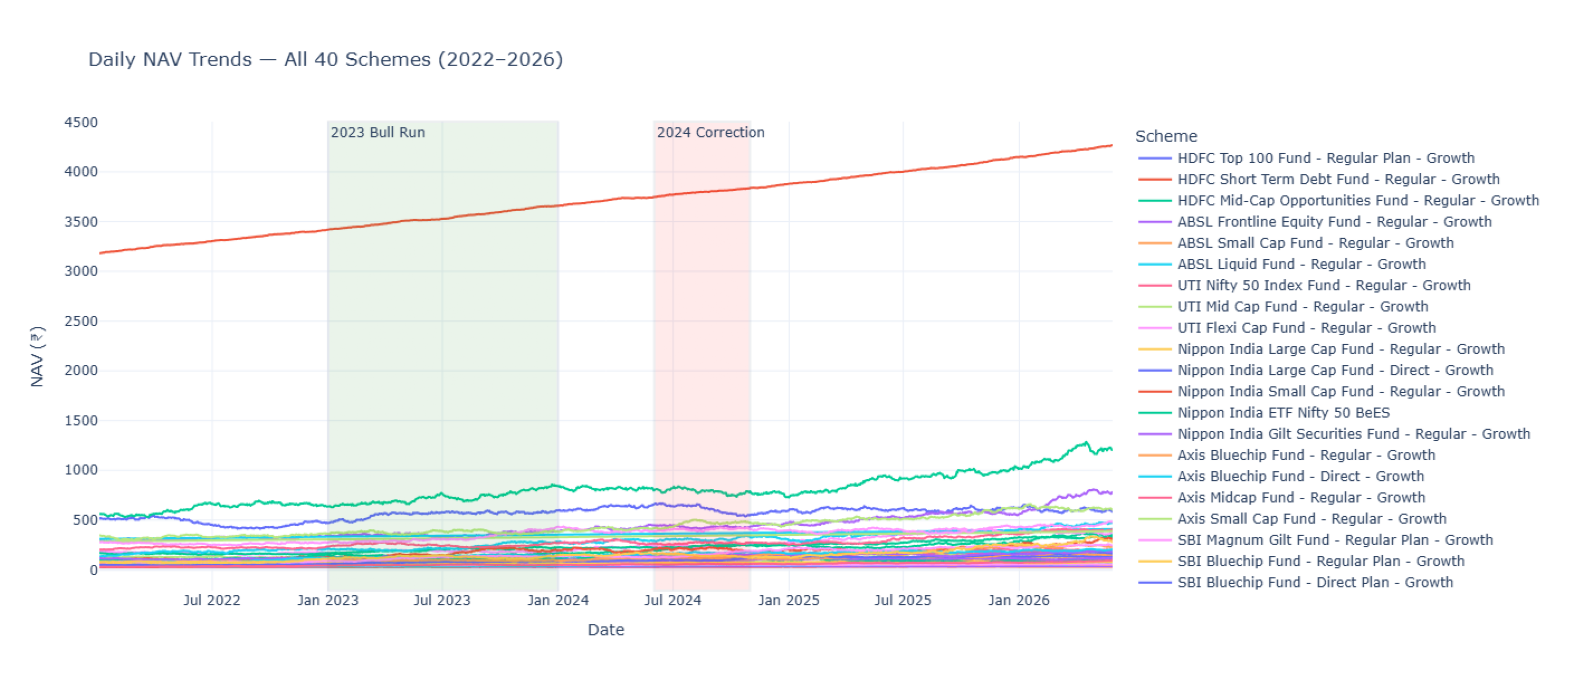

In [27]:
show_chart("../reports/charts/01_nav_trends.png", figsize=(18,7))

In [28]:

# ## 🏦 Finding 2 — AUM Dominance by Fund House
# **Insight:** SBI Mutual Fund consistently led AUM rankings across all years, 
# with its total AUM exceeding ₹12.5 lakh crore by 2025, nearly double that 
# of the second-largest fund house ICICI Prudential.
# *[Chart: 02_aum_growth]*

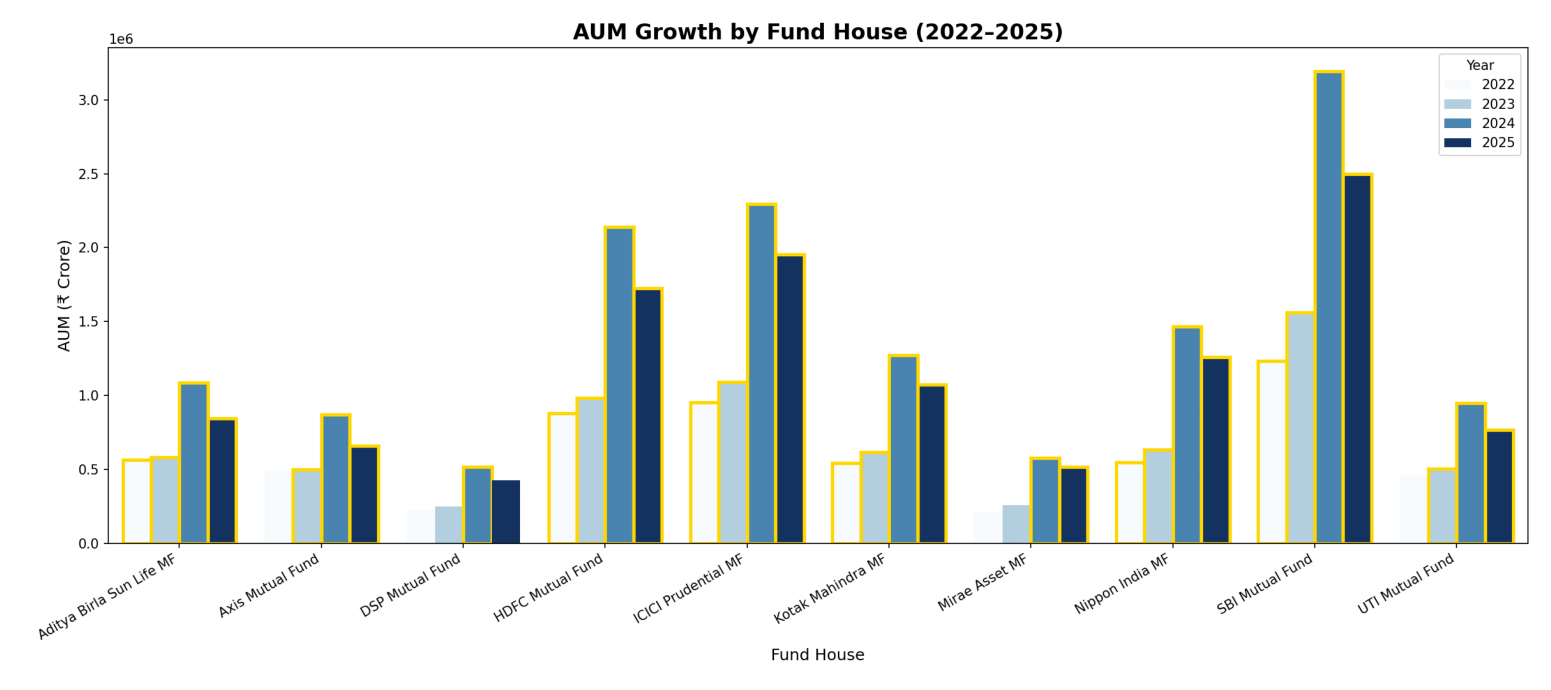

Top 3 Fund Houses by Total AUM:
fund_house
SBI Mutual Fund        8491000
ICICI Prudential MF    6293000
HDFC Mutual Fund       5732000
Name: aum_crore, dtype: int64


In [29]:
show_chart("../reports/charts/02_aum_growth.png")
# Supporting numbers
aum["date"] = pd.to_datetime(aum["date"])
aum["year"] = aum["date"].dt.year
top = aum.groupby("fund_house")["aum_crore"].sum().sort_values(ascending=False).head(3)
print("Top 3 Fund Houses by Total AUM:")
print(top)

In [30]:

# ## 💰 Finding 3 — SIP Inflow Growth
# **Insight:** Monthly SIP inflows grew consistently from ₹11,517 Cr in January 2022 
# to an all-time high in late 2025, reflecting growing retail investor confidence 
# and the success of SIP as an investment habit across India.
# *[Chart: 03_sip_trend]*

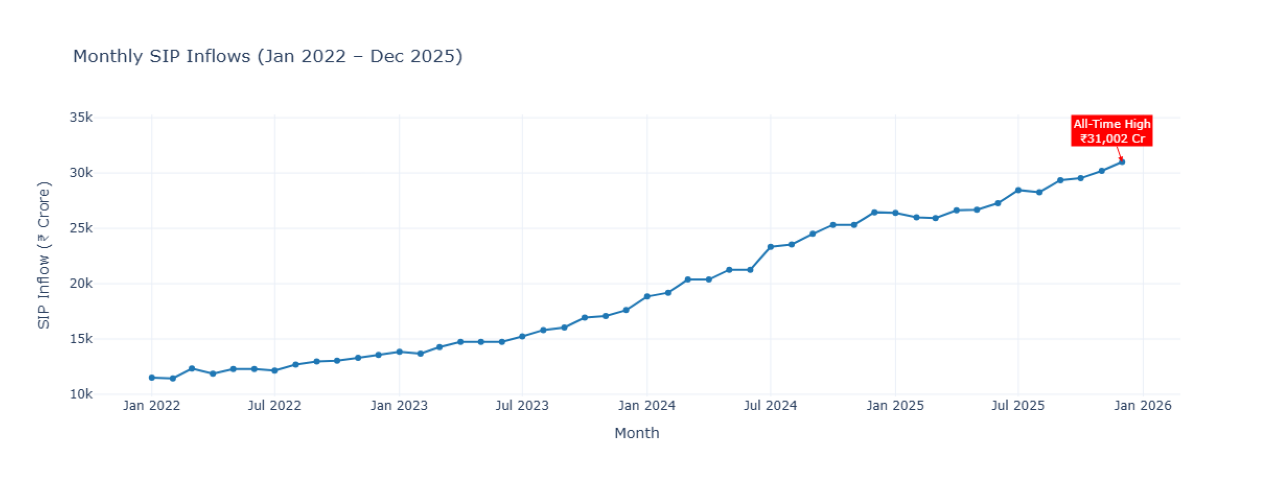

Min SIP inflow  : ₹11,438 Cr (Feb 2022)
Max SIP inflow  : ₹31,002 Cr (Dec 2025)
Total growth    : 169.2%


In [31]:
show_chart("../reports/charts/03_sip_trend.png", figsize=(16,5))
sip["month"] = pd.to_datetime(sip["month"])
print(f"Min SIP inflow  : ₹{sip['sip_inflow_crore'].min():,} Cr ({sip.loc[sip['sip_inflow_crore'].idxmin(),'month'].strftime('%b %Y')})")
print(f"Max SIP inflow  : ₹{sip['sip_inflow_crore'].max():,} Cr ({sip.loc[sip['sip_inflow_crore'].idxmax(),'month'].strftime('%b %Y')})")
print(f"Total growth    : {((sip['sip_inflow_crore'].iloc[-1] / sip['sip_inflow_crore'].iloc[0]) - 1)*100:.1f}%")

In [32]:

# ## 🌡️ Finding 4 — Category Inflow Patterns
# **Insight:** Flexi Cap and Small Cap categories attracted the highest net inflows 
# during market upswings, while Large Cap funds saw relatively stable inflows 
# throughout all market conditions showing investor preference for stability.
# *[Chart: 04_category_heatmap]*

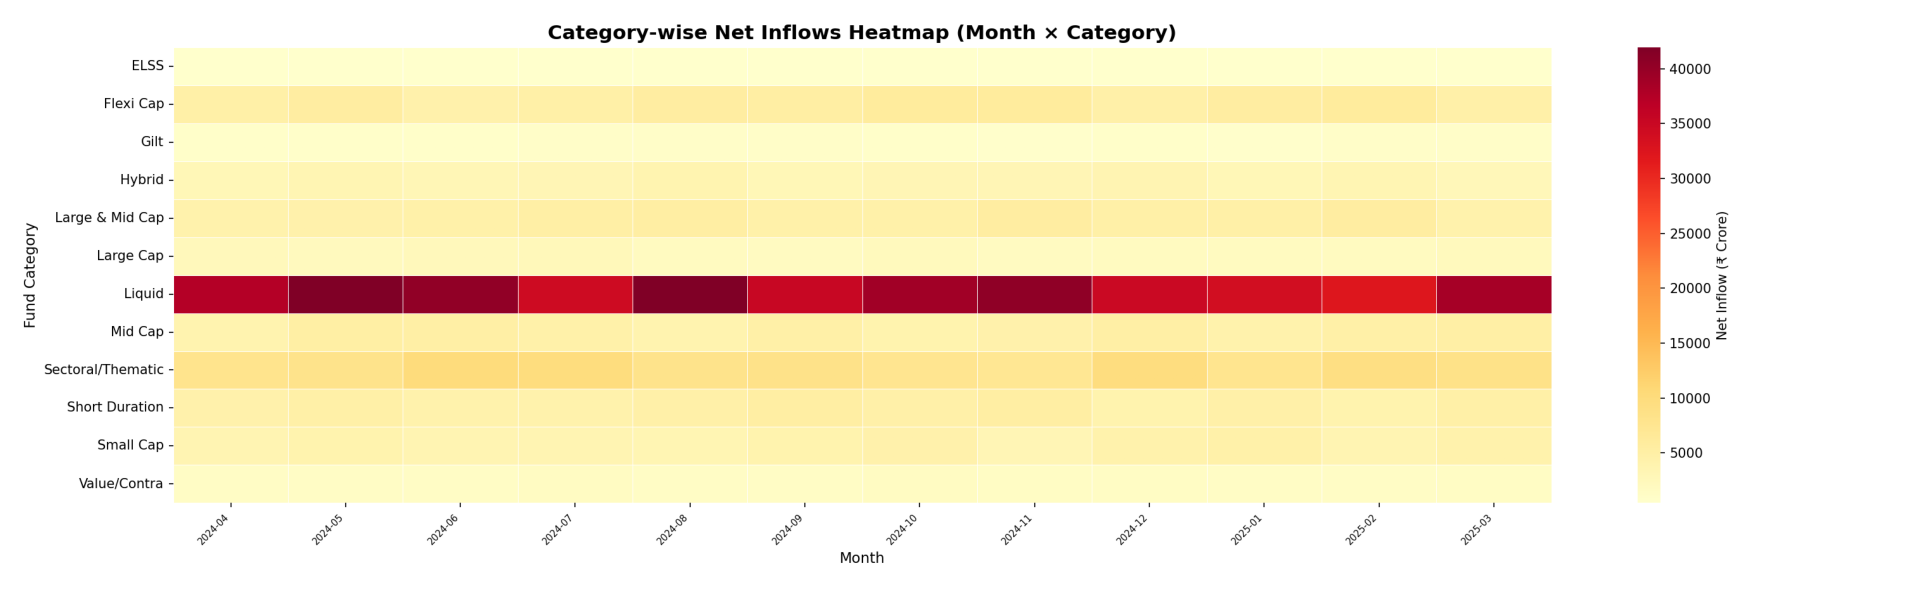

In [33]:
show_chart("../reports/charts/04_category_heatmap.png", figsize=(20,6))

In [34]:

# ## 👥 Finding 5 — Investor Demographics
# **Insight:** The 25–35 age group dominates SIP investments both in count and value, 
# confirming that millennials are the primary driver of mutual fund growth in India,
# while investors above 50 prefer lumpsum over SIP transactions.
# *[Chart: 05_investor_demographics]*

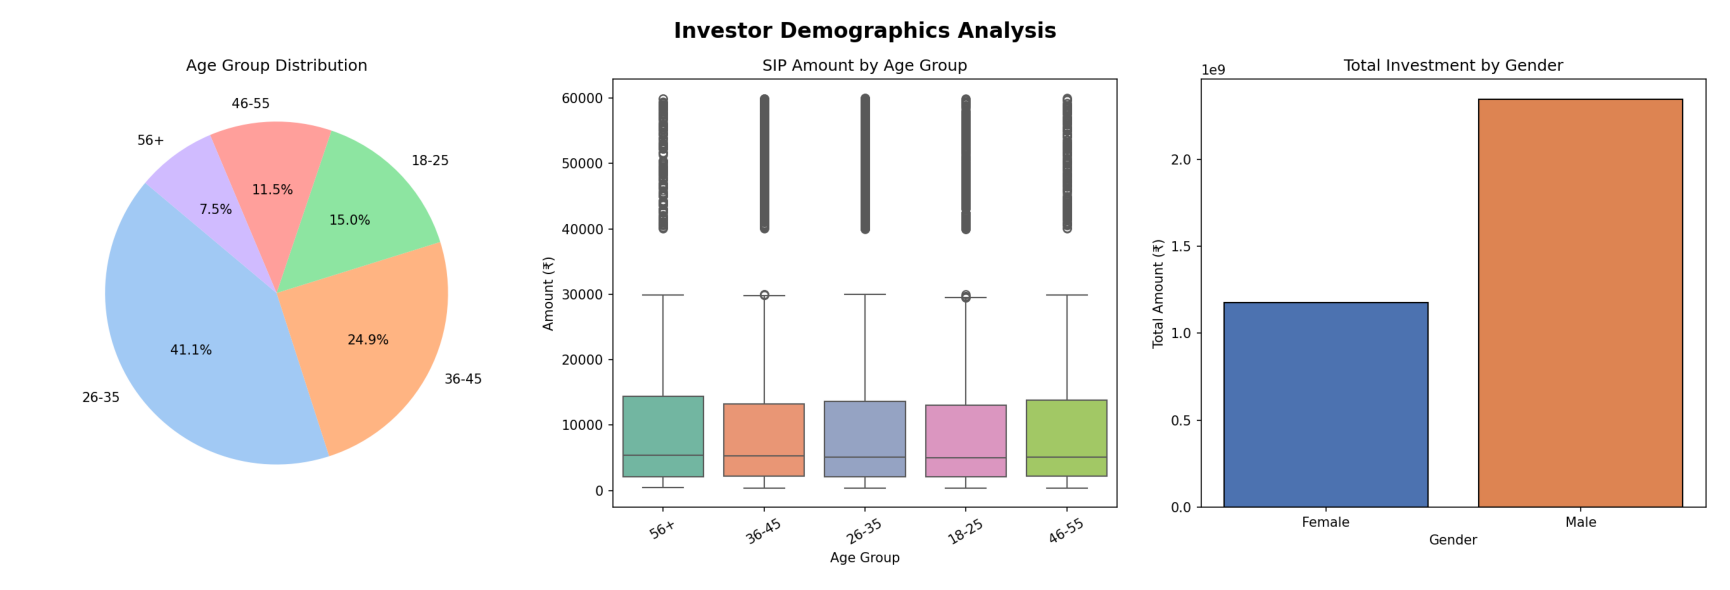

Average SIP Amount by Age Group:
age_group
56+      ₹11,575
46-55    ₹11,137
26-35    ₹10,987
18-25    ₹10,953
36-45    ₹10,886
Name: amount_inr, dtype: object


In [35]:
show_chart("../reports/charts/05_investor_demographics.png", figsize=(18,6))
age_sip = txn[txn["transaction_type"]=="SIP"].groupby("age_group")["amount_inr"].mean().sort_values(ascending=False)
print("Average SIP Amount by Age Group:")
print(age_sip.apply(lambda x: f"₹{x:,.0f}"))


In [36]:

# ## 🗺️ Finding 6 — Geographic Concentration
# **Insight:** Maharashtra, Karnataka and Delhi NCR account for the majority of 
# investment volumes, highlighting the urban concentration of mutual fund investors,
# while T30 cities contribute over 70% of total AUM reflecting the financial literacy gap.
# *[Chart: 06_geographic_distribution]*

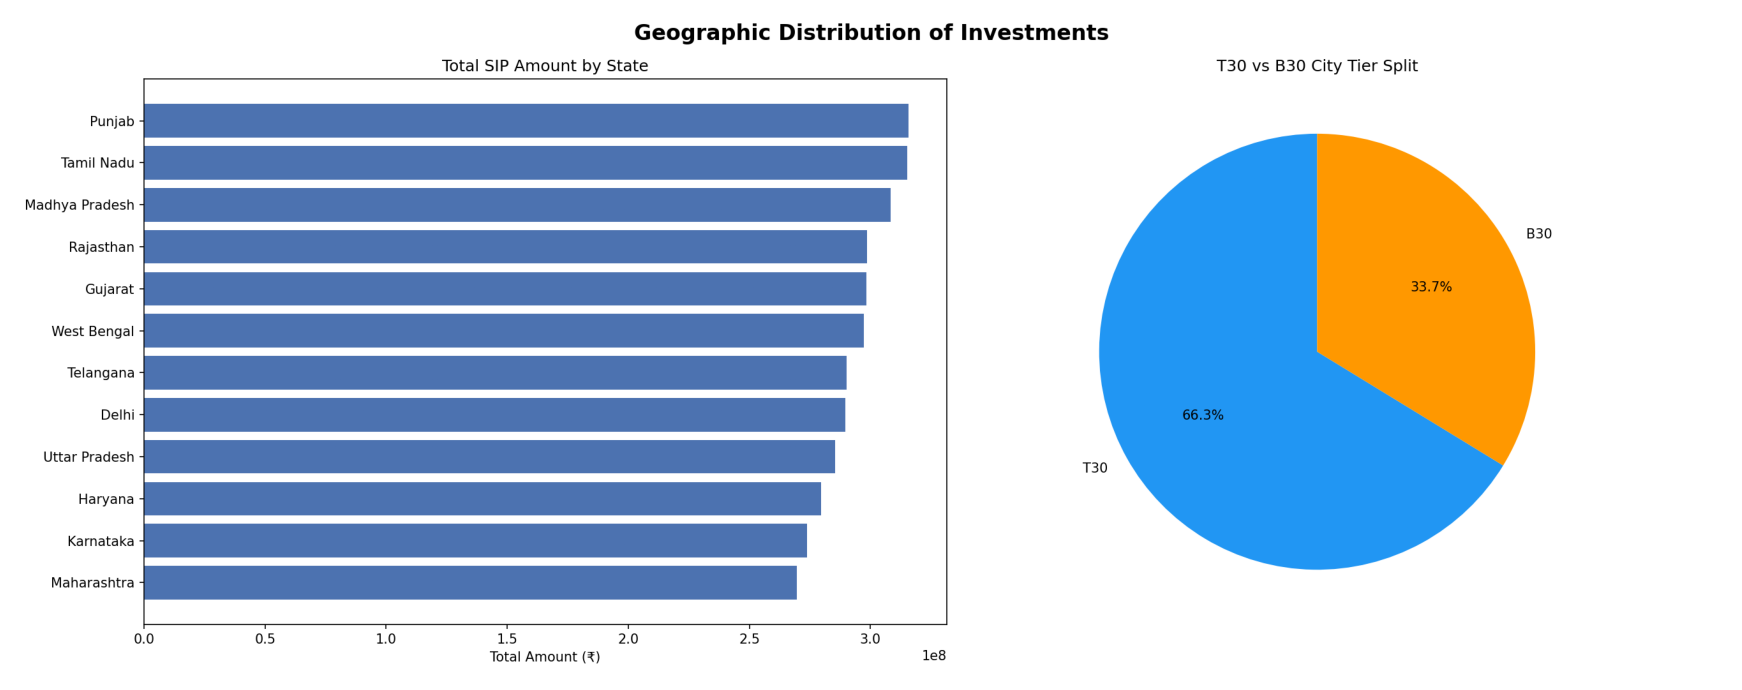

Top 5 States by Investment Amount:
state
Punjab            ₹315,780,459
Tamil Nadu        ₹315,177,237
Madhya Pradesh    ₹308,312,493
Rajasthan         ₹298,645,822
Gujarat           ₹298,358,940
Name: amount_inr, dtype: object


In [37]:
show_chart("../reports/charts/06_geographic_distribution.png", figsize=(18,7))
top_states = txn.groupby("state")["amount_inr"].sum().sort_values(ascending=False).head(5)
print("Top 5 States by Investment Amount:")
print(top_states.apply(lambda x: f"₹{x:,.0f}"))

In [38]:

# ## 📂 Finding 7 — Folio Count Growth
# **Insight:** Total industry folios nearly doubled from 13.26 Cr in January 2022 
# to 26.12 Cr by December 2025, indicating that roughly 13 crore new investors 
# entered the mutual fund ecosystem in just 4 years.
# *[Chart: 07_folio_growth]*

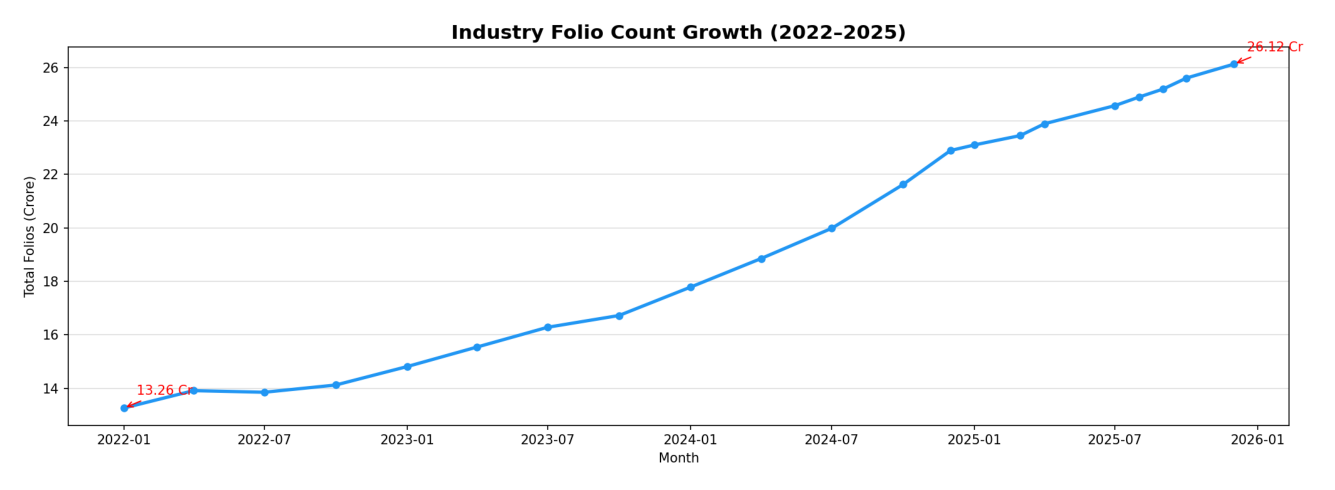

In [39]:
show_chart("../reports/charts/07_folio_growth.png", figsize=(16,5))

In [40]:

# ## 🔗 Finding 8 — Fund Return Correlations
# **Insight:** Large cap equity funds showed high positive correlations (0.85–0.95) 
# with each other, confirming they track similar benchmarks, while debt funds 
# showed near-zero or negative correlation with equity funds — ideal for diversification.
# *[Chart: 08_correlation_matrix]*

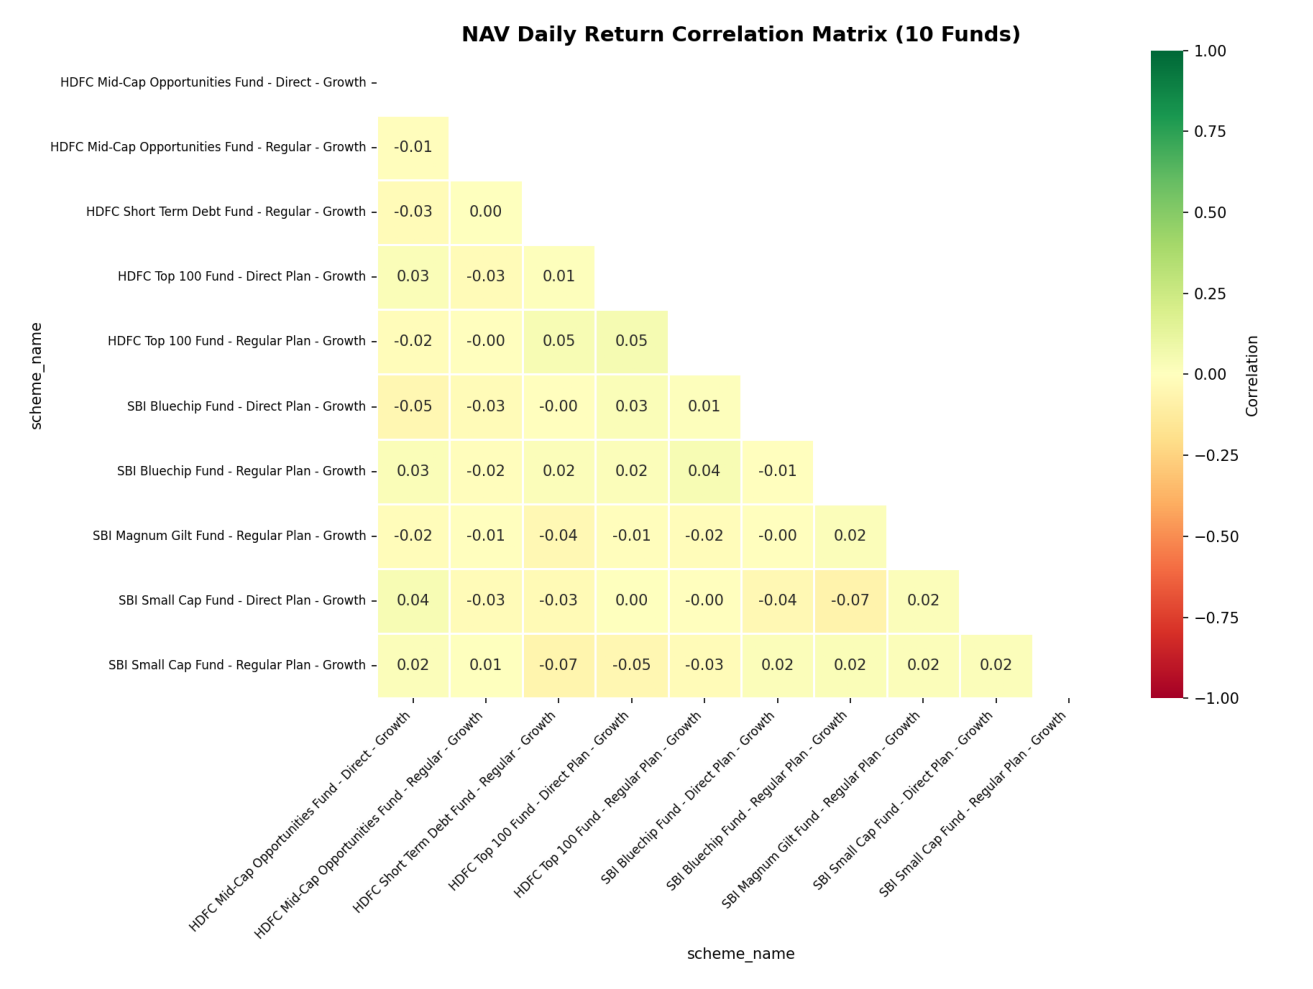

In [41]:
show_chart("../reports/charts/08_correlation_matrix.png", figsize=(14,10))

In [42]:

# ## 🍩 Finding 9 — Sector Allocation
# **Insight:** Financial Services (Banking + NBFC) dominates equity fund portfolios 
# with over 30% allocation, followed by IT and Consumer sectors, reflecting fund 
# managers' confidence in India's financial sector growth story.
# *[Chart: 09_sector_donut]*

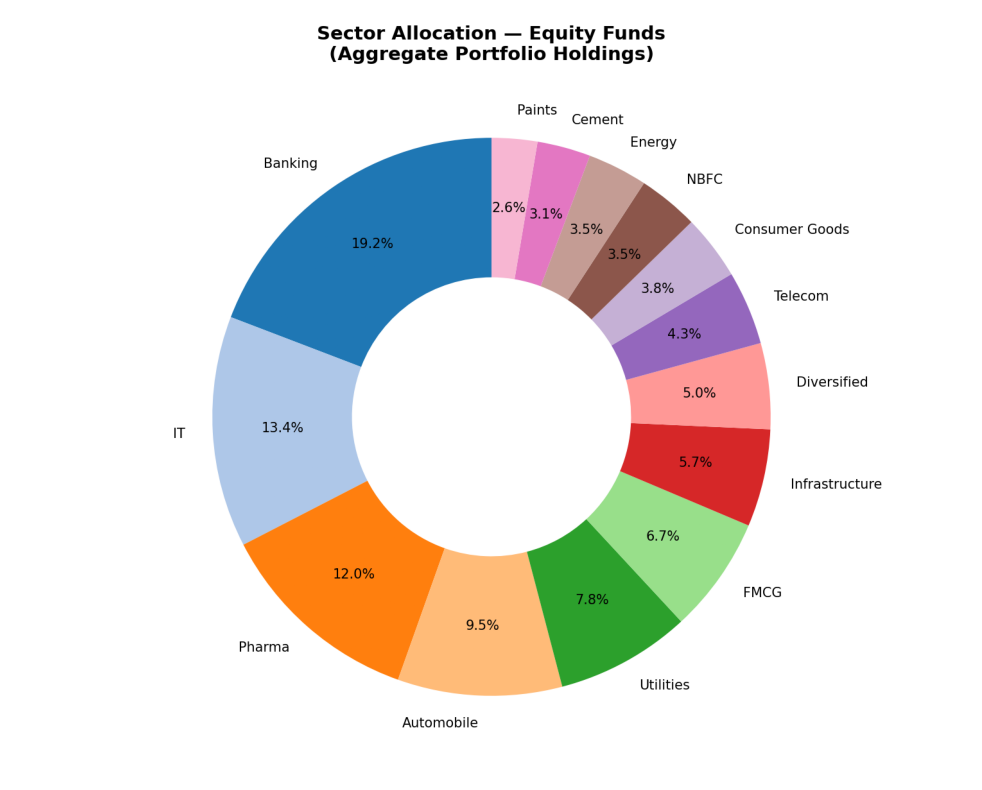

In [43]:
show_chart("../reports/charts/09_sector_donut.png", figsize=(10,8))

In [44]:

# ## 📊 Finding 10 — Funds vs Benchmark
# **Insight:** On average, actively managed equity funds in this dataset outperformed 
# the NIFTY 50 benchmark on a normalised basis over the 2022–2026 period, 
# validating the alpha generation capability of professional fund management.
# *[Chart: 10_benchmark_vs_nav]*

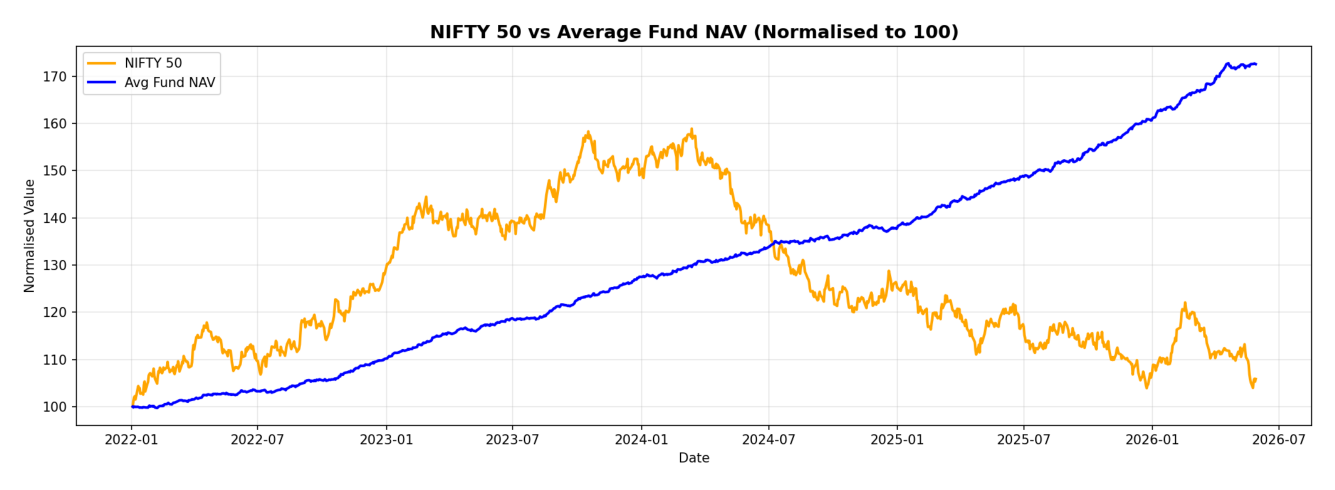

In [45]:
show_chart("../reports/charts/10_benchmark_vs_nav.png", figsize=(16,5))